## Úloha 1 - Porovnávání šablon

V této úloze budeme řešit problémy s hledáním šablony v obrázku.

## Import knihoven

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Binární obrázek

1. vytvoříme obrázek křížku (naše šablona), pixely mohou být pouze 0 nebo 1, šablona bude 5x5 pixelů
1. vytvoříme obrázek 100 x 100 pixelů, na 3 místa umístímě naši šablonu, tak aby se nepřekrývala
1. napíšeme funkci, která nám vrátí souřadnice všech křížků

Nalezené souřadnice (y, x): [(10, 10), (40, 55), (75, 30)]


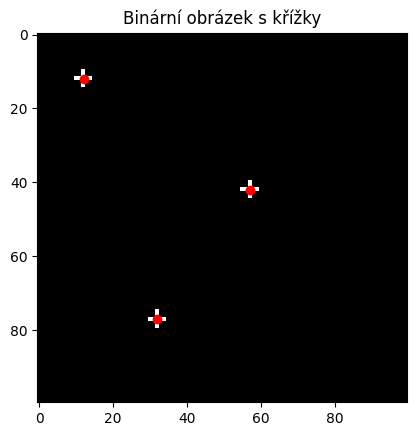

In [2]:
# šablona křížku 5x5 (binární)
template = np.zeros((5, 5), dtype=np.float32)
template[2, :] = 1
template[:, 2] = 1

# obrázek 100x100 se třemi nepřekrývajícími se křížky
img = np.zeros((100, 100), dtype=np.float32)
positions = [(10, 10), (40, 55), (75, 30)]  # (y, x)
for y, x in positions:
    img[y:y + 5, x:x + 5] = template


def find_crosses_binary(img, template):
    """Najde přesné shody šablony v binárním obraze (okno po okně)."""
    th, tw = template.shape
    coords = []
    for y in range(img.shape[0] - th + 1):
        for x in range(img.shape[1] - tw + 1):
            patch = img[y:y + th, x:x + tw]
            if np.array_equal(patch, template):
                coords.append((y, x))
    return coords


found = find_crosses_binary(img, template)
print("Nalezené souřadnice (y, x):", found)

plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.title("Binární obrázek s křížky")
for y, x in found:
    plt.plot(x + 2, y + 2, "ro")  # střed nalezeného křížku
plt.show()

## Stupně šedi

Co se změní, když pixely budou nabývat hodnot 0 až 1? Diskuze:
1. vzdálenost
1. prahování

Po diskuzi upravte funkci, aby zvládla stupně šedi.

Nalezené souřadnice (stupně šedi): [(10, 10), (40, 55), (75, 30)]


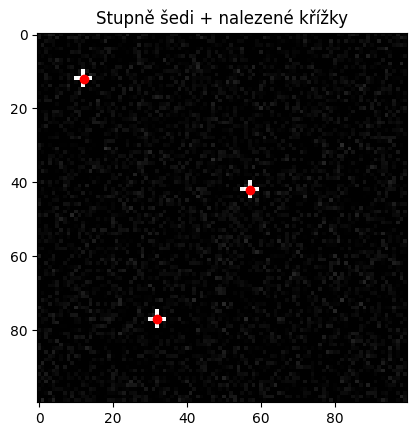

In [3]:
# u stupňů šedi už nestačí přesná shoda (array_equal):
# - měříme vzdálenost (např. součet čtverců rozdílů = SSD)
# - výsledek prahujeme: pokud je vzdálenost pod prahem, považujeme místo za shodu

img_gray = img.copy()
# lehce „zašumíme“ / změníme intenzity, aby to nebyla přesná 0/1 shoda
np.random.seed(0)
img_gray = np.clip(img_gray + np.random.normal(0, 0.05, img_gray.shape), 0, 1).astype(np.float32)


def find_crosses_gray(img, template, threshold=0.5):
    """Najde šablonu ve stupních šedi pomocí SSD a prahování."""
    th, tw = template.shape
    coords = []
    for y in range(img.shape[0] - th + 1):
        for x in range(img.shape[1] - tw + 1):
            patch = img[y:y + th, x:x + tw]
            ssd = np.sum((patch - template) ** 2)
            if ssd < threshold:
                coords.append((y, x))
    return coords


found_gray = find_crosses_gray(img_gray, template, threshold=0.5)
print("Nalezené souřadnice (stupně šedi):", found_gray)

plt.imshow(img_gray, cmap="gray", vmin=0, vmax=1)
plt.title("Stupně šedi + nalezené křížky")
for y, x in found_gray:
    plt.plot(x + 2, y + 2, "ro")
plt.show()

## Speciální šablony

1. detekce hrany v jednom směru
1. ukázka v `opencv`

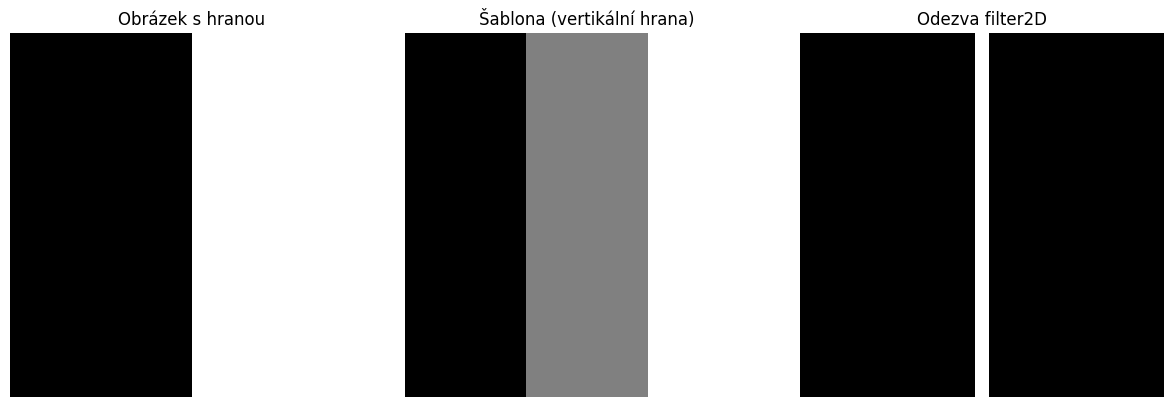

Nejlepší shoda (TM_SQDIFF) na pozici (x, y): (10, 10) SSD = 0.0


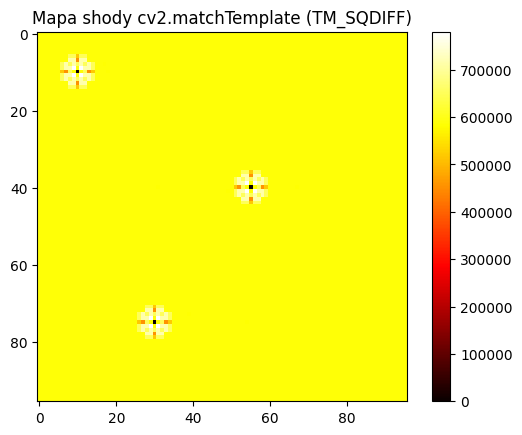

In [4]:
# jednoduchá šablona pro vertikální hranu (přechod tmavé → světlé)
edge_template = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=np.float32)

# testovací obrázek s vertikální hranou
edge_img = np.zeros((50, 50), dtype=np.float32)
edge_img[:, 25:] = 1.0

# vlastní korelace (podobné porovnávání šablon)
response = cv2.filter2D(edge_img, ddepth=-1, kernel=edge_template)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(edge_img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Obrázek s hranou")
axes[1].imshow(edge_template, cmap="gray")
axes[1].set_title("Šablona (vertikální hrana)")
axes[2].imshow(response, cmap="gray")
axes[2].set_title("Odezva filter2D")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# ukázka v OpenCV: matchTemplate
img_u8 = (img * 255).astype(np.uint8)
template_u8 = (template * 255).astype(np.uint8)
result = cv2.matchTemplate(img_u8, template_u8, cv2.TM_SQDIFF)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
print("Nejlepší shoda (TM_SQDIFF) na pozici (x, y):", min_loc, "SSD =", min_val)

plt.imshow(result, cmap="hot")
plt.title("Mapa shody cv2.matchTemplate (TM_SQDIFF)")
plt.colorbar()
plt.show()